<a href="https://colab.research.google.com/github/SinelnikovaJulia/Stat_practicum/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Разведочный анализ данных

In [2]:
import warnings
warnings.filterwarnings("ignore")


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
import random

from torch.utils.data import TensorDataset, DataLoader

from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid, KFold
from sklearn.metrics import accuracy_score

In [4]:
 #Список имён для 57 признаков (взят из документации UCI)
word_freq_cols = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference'
]

char_freq_cols = [
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#'
]

capital_cols = [
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

# Все имена признаков (57)
feature_names = word_freq_cols + char_freq_cols + capital_cols
print(f"Общее количество признаков: {len(feature_names)}")

Общее количество признаков: 57


In [5]:
dataset = pd.read_csv("/content/drive/MyDrive/spambase.data",
                 header = None,
                names=feature_names + ['spam'])
#dataset.rename(columns={dataset.columns[-1]: 'класс'}, inplace=True)
#print(dataset.head())

Давайте получим базовое описание текущего dataset.
Для начала рассмотрим несколько случайных фич и как они отражаются на классификации спам/не спам

In [6]:
random.seed(42)
features = dataset.columns[:-1]

cols = random.sample(list(features), 5)
#print(cols)
#cols = cols.append(pd.Index([dataset.columns[-1]]))
cols = cols + [dataset.columns[-1]]
#print(cols)
dataset.loc[:, cols].describe()
#dataset.sample(6).describe()

,word_freq_cs,word_freq_internet,word_freq_address,word_freq_conference,word_freq_email,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.043667,0.105295,0.213015,0.031869,0.184745,0.394045
std,0.361205,0.401071,1.290575,0.285735,0.531122,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,7.140000,11.110000,14.280000,10.000000,9.090000,1.000000


In [8]:
dataset.groupby('spam').mean()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
spam,,,,,,,,,,,,,,,,,,,,,
0,0.073479,0.244466,0.200581,0.000886,0.181040,0.044544,0.009383,0.038415,0.038049,0.167170,...,0.051227,0.050281,0.158578,0.022684,0.109984,0.011648,0.021713,2.377301,18.214491,161.470947
1,0.152339,0.164650,0.403795,0.164672,0.513955,0.174876,0.275405,0.208141,0.170061,0.350507,...,0.002101,0.020573,0.108970,0.008199,0.513713,0.174478,0.078877,9.519165,104.393271,470.619415


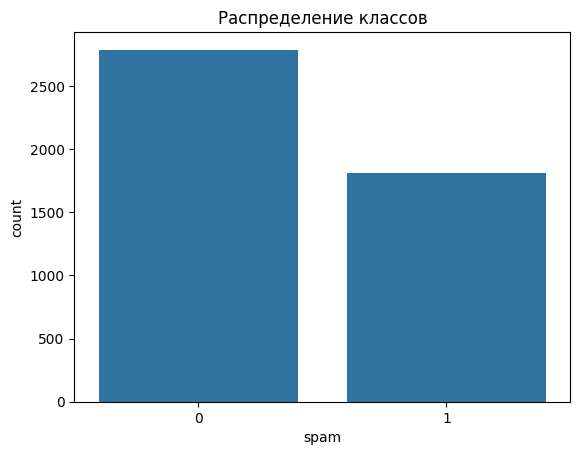

spam
0    0.605955
1    0.394045
Name: proportion, dtype: float64


In [9]:
sns.countplot(x='spam', data=dataset)
plt.title('Распределение классов')
plt.show()

print(dataset['spam'].value_counts(normalize=True))

**Выясним теперь такую вещь:**
1) Рассмотрим среднюю частоту каждого признака для писем - спама и писем - не спама
2) Найдем отношение средней частоты каждого признака в письмах-спаме к средней частоте в признаках не спаме
3) Определим те признаки, которые гораздо чаще встречаются в спаме, нежели не в спаме
4) Выдвигаем гипотезу, что эти признаки больше коррелируют со спамом

In [10]:
#new_df = np.sum(dataset['spam'==1])
#new_df = new_df/(len(dataset))
spam_df = dataset[dataset['spam']== 1]
no_spam_df = dataset[dataset['spam']== 0]
spam_df.drop(columns =['capital_run_length_total',
                       'capital_run_length_longest',
                       'capital_run_length_average', 'spam'], inplace = True)

no_spam_df.drop(columns =['capital_run_length_total',
                        'capital_run_length_longest',
                        'capital_run_length_average', 'spam'], inplace = True)
spam_df = (spam_df.sum(axis = 0)/((len(dataset))))
no_spam_df = (no_spam_df.sum(axis =0)/((len(dataset))))
otnos_df = spam_df / no_spam_df
#print(type(new_df))
#new_df = new_df.sort_values(ascending=False)
otnos_df = otnos_df.sort_values(ascending=False)
#print(no_spam_df)
#print(new_df)
print(otnos_df.head())

word_freq_3d        120.870445
word_freq_000        22.667510
word_freq_remove     19.086774
word_freq_credit     17.634169
char_freq_$           9.740393
dtype: float64


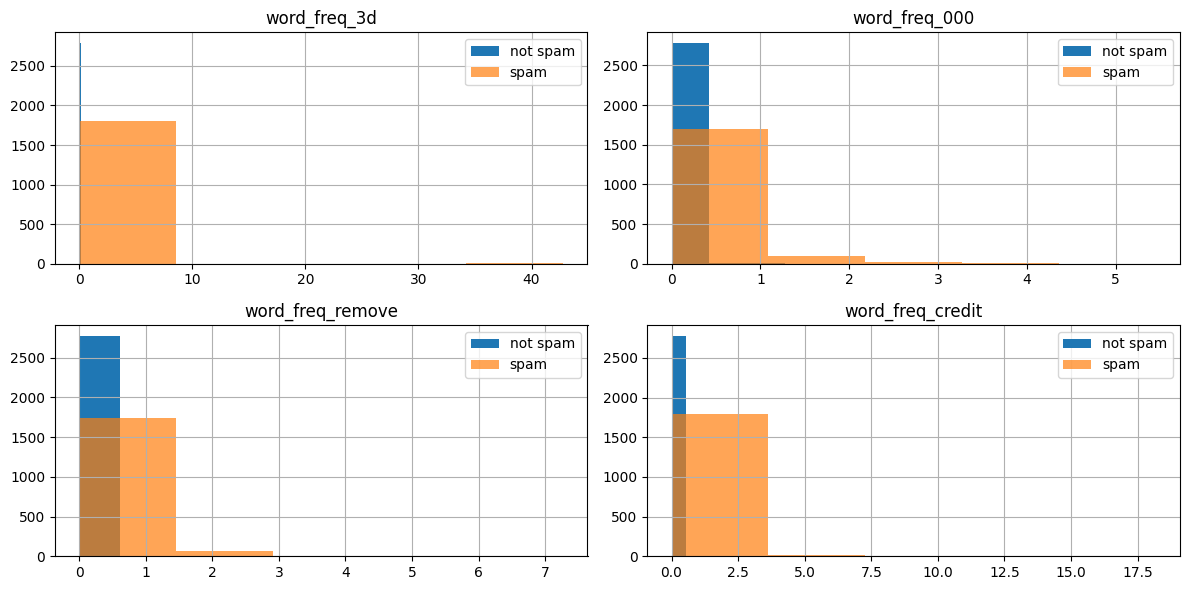

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
features_to_plot = ['word_freq_3d', 'word_freq_000', 'word_freq_remove', 'word_freq_credit']

for ax, feat in zip(axes.ravel(), features_to_plot):
    dataset[dataset['spam']==0][feat].hist(ax=ax, alpha=1, label='not spam', bins=5)
    dataset[dataset['spam']==1][feat].hist(ax=ax, alpha=0.7, label='spam', bins=5)
    ax.set_title(feat)
    ax.legend(loc = 'best')
plt.tight_layout()
plt.show()

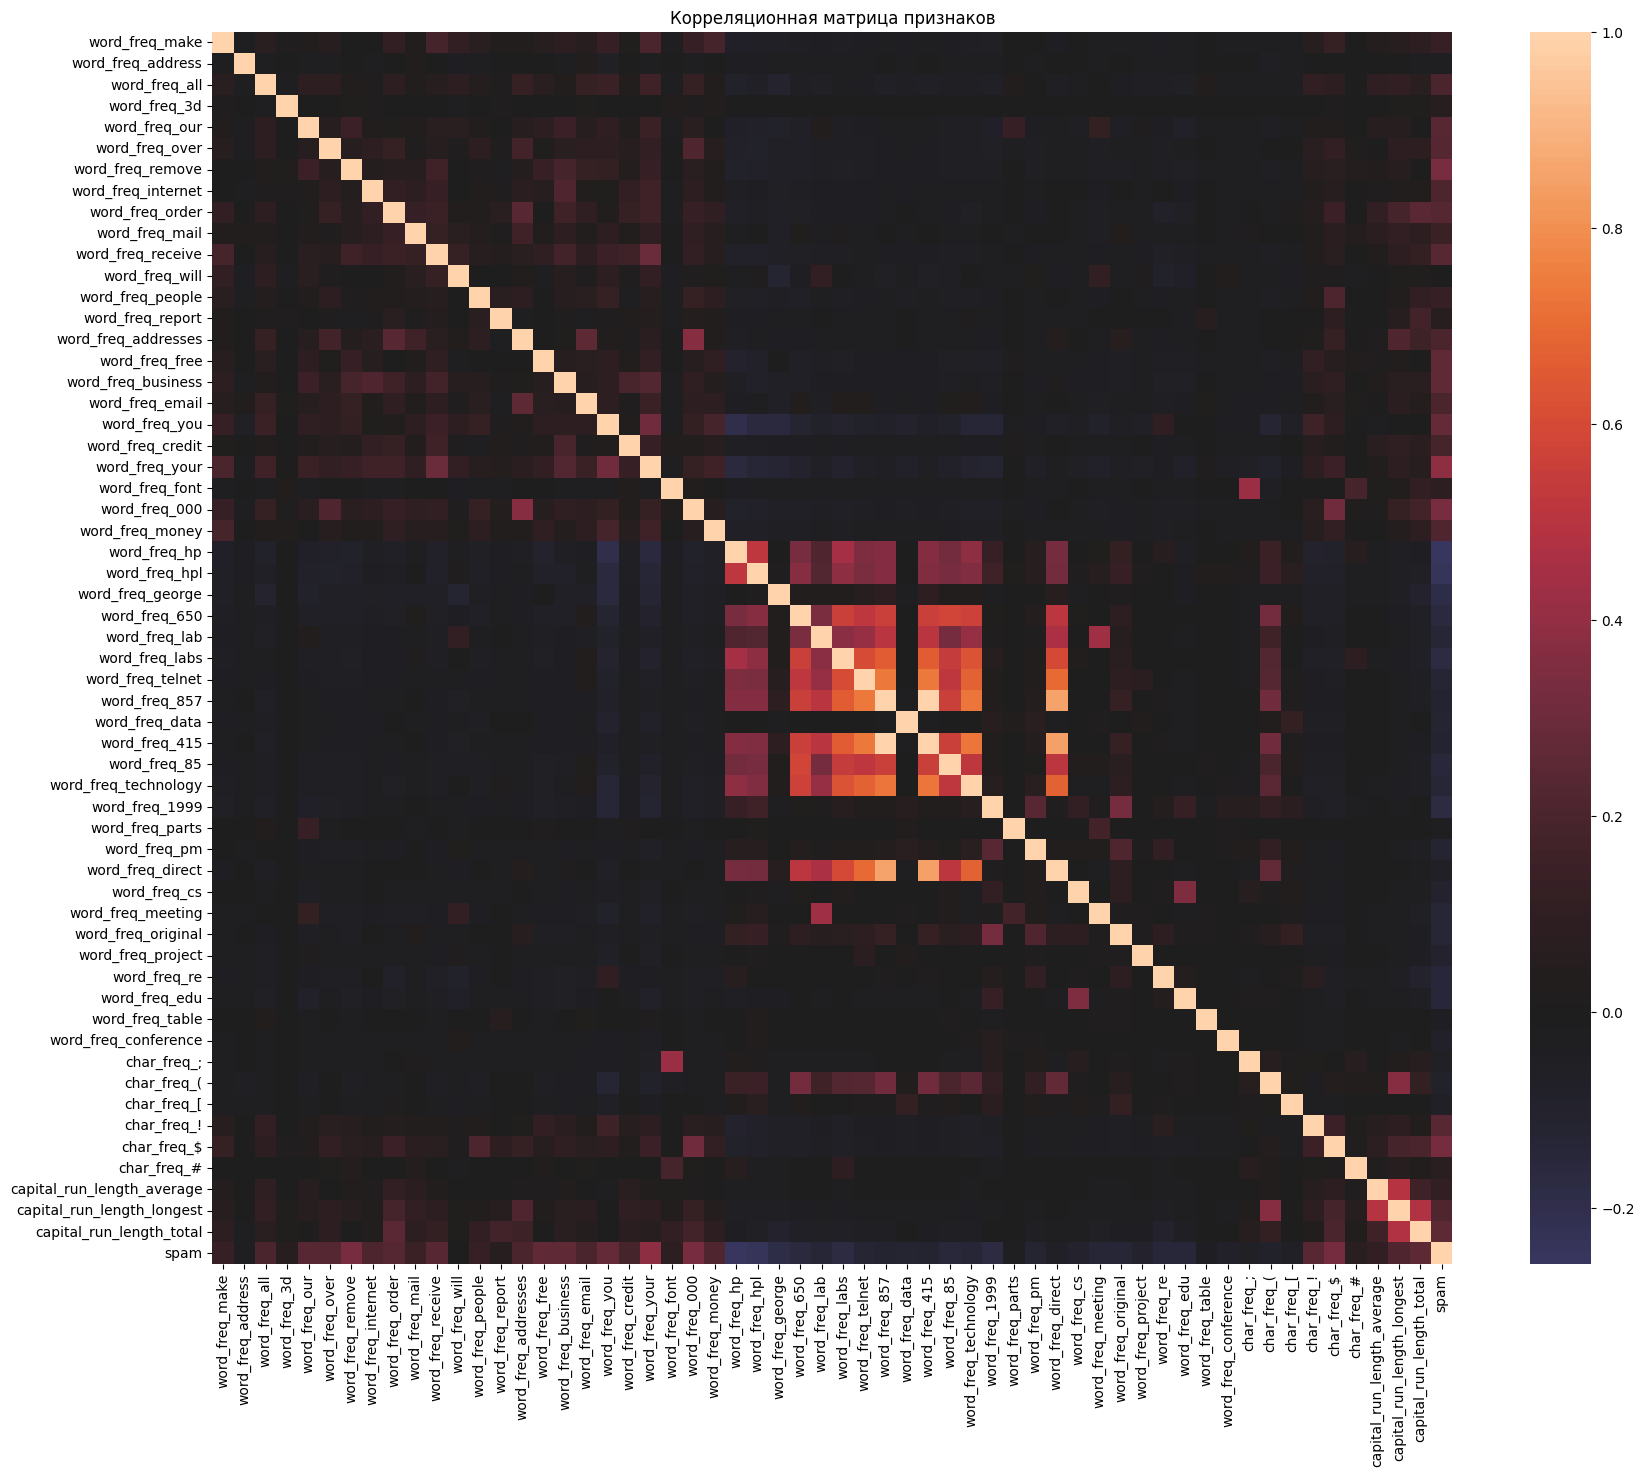

In [12]:
# Вычислим корреляцию
corr_matrix = dataset.corr()
#print(type(corr_matrix))
# Визуализируем
plt.figure(figsize=(20, 16))

sns.heatmap(corr_matrix, center=0, annot=False, fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

In [13]:
corr_with_spam = corr_matrix['spam'].sort_values(ascending=False)

print("Топ-10 признаков, коррелирующих со спамом:")
print(corr_with_spam[1:11])

Топ-10 признаков, коррелирующих со спамом:
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_!                 0.241888
Name: spam, dtype: float64


## Короткий вывод по результатам EDA

На основе разведочного анализа набора данных Spambase можно сделать следующие ключевые выводы:

1. **Наиболее информативные признаки** – частоты встречаемости определённых слов и символов значительно выше в спам-письмах.  
   - Лидерами по отношению средней частоты в спаме к не спаму стали `word_freq_3d`, `word_freq_000`, `word_freq_remove`, `word_freq_credit`, `char_freq_$`.  
   - Эти признаки имеют ярко выраженные различия в распределениях между классами.

3. **Корреляционный анализ подтвердил значимость выделенных признаков**.  
   Топ-10 признаков, наиболее сильно коррелирующих со спамом, включает:  
   `word_freq_your`, `word_freq_000`, `word_freq_remove`, `char_freq_$`, `word_freq_you`, `word_freq_free`, `word_freq_business`, `capital_run_length_total`, `word_freq_our`, `char_freq_!`.  
   Это указывает на то, что спам часто содержит финансовую лексику, восклицательные знаки, символ доллара и обращения к получателю.

4. **Признаки, связанные с длиной заглавных серий** (особенно `capital_run_length_total`) также положительно коррелируют со спамом, что согласуется с типичным «кричащим» оформлением спам-писем.

**Итог:** EDA показал, что спам легко отделим от нормальных писем по частоте ключевых слов и символов, а также по стилистическим особенностям (капитализация, восклицания). Эти признаки можно напрямую использовать для построения эффективных классификационных моделей.


Задачу классификации планирую выполнить с помощью логистической регрессии и многослойной нейронной сети